# Placements made

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb as ddb
import numpy as np

### Loading Data

In [2]:
con = ddb.connect(database=":memory:")

# Load data
con.execute(f"""CREATE OR REPLACE VIEW rc_pbfd AS SELECT * FROM read_parquet('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/capacity_based_results/RC_PBFD/placements_RC_PBFD.parquet')""")

In [5]:

con.query(f"""CREATE OR REPLACE TABLE vmhardware AS SELECT * FROM read_csv('/Users/biancachiusano/Desktop/uva/thesis/energy-aware-vm-consolidation/datasets/cloud_energy_consumption/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms_fixed.csv')""")

In [6]:
con.query("""SELECT * from vmhardware LIMIT 5""").show()

┌──────────┬──────────┬────────────┬───────────┬────────┬───────────┬─────────┬──────────────┐
│  vm_id   │ user_id  │ project_id │ image_ref │ vcpus  │ memory_mb │ root_gb │ ephemeral_gb │
│ varchar  │ varchar  │  varchar   │  varchar  │ double │  double   │ double  │    double    │
├──────────┼──────────┼────────────┼───────────┼────────┼───────────┼─────────┼──────────────┤
│ 6239bcf4 │ 39786247 │ 4ba6ce42   │ 85ecdff4  │   32.0 │   60000.0 │    30.0 │        160.0 │
│ 80458243 │ bd41a7e4 │ 74dfdf00   │ cb92696e  │    1.0 │    2000.0 │    10.0 │         20.0 │
│ 5d9f6237 │ 7190ddfa │ 906147a9   │ 78c5906a  │    4.0 │    7500.0 │    30.0 │         60.0 │
│ 941785dc │ 1a324c91 │ f09054da   │ 23658854  │    2.0 │    4000.0 │    10.0 │        100.0 │
│ fb856e0f │ c1eb1c1c │ f09054da   │ c015d680  │    4.0 │    7500.0 │    30.0 │         60.0 │
└──────────┴──────────┴────────────┴───────────┴────────┴───────────┴─────────┴──────────────┘



### Counts

In [4]:
con.query("""
    SELECT
        COUNT(DISTINCT vm_id) AS unique_vm_ids,
        COUNT(DISTINCT source_node) AS unique_source_nodes,
        COUNT(DISTINCT target_node) AS unique_target_nodes
    FROM rc_pbfd
""").show()

┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64     │        int64        │        int64        │
├───────────────┼─────────────────────┼─────────────────────┤
│           375 │                  77 │                  56 │
└───────────────┴─────────────────────┴─────────────────────┘



### Are some VM's migrated more than others?
### Are some users disproportionately affected by migrations

In [15]:
vm_user = con.query("""SELECT vm_id, user_id from vmhardware""").df()

vm_migrations = con.query("""
    SELECT vm_id, COUNT(*) AS migrations
    FROM rc_pbfd
    GROUP BY vm_id
""").df()

user_migrations = vm_migrations.merge(vm_user, on="vm_id", how="left")
user_migrations = user_migrations.groupby("user_id")["migrations"].sum().reset_index()
user_vm_count = vm_user.groupby("user_id")["vm_id"].count().reset_index(name="num_vms")

user_migrations = user_migrations.merge(user_vm_count, on="user_id")

user_migrations["migrations_per_vm"] = (
    user_migrations["migrations"] / user_migrations["num_vms"]
)
user_migrations.head()

,user_id,migrations,num_vms,migrations_per_vm
0,0fb4c56f,32361,102,317.264706
1,1004f468,1106,1,1106.000000
2,10175724,1501,1,1501.000000
3,110713be,516,1,516.000000
4,167938a6,30211,16,1888.187500


In [16]:
user_migrations.sort_values("migrations_per_vm", ascending=False).head(10)

,user_id,migrations,num_vms,migrations_per_vm
23,7043311c,70684,7,10097.714286
31,8984204a,45202,8,5650.250000
37,97f5bcf7,29670,6,4945.000000
57,fe56c37c,16193,4,4048.250000
33,90e4d383,11790,3,3930.000000
50,de65e922,7141,2,3570.500000
36,94d5b733,12818,4,3204.500000
10,37499268,2954,1,2954.000000
15,4a88a504,23883,9,2653.666667
17,4de194f3,5171,2,2585.500000


Users have a different number of VMs so I need to normalise

#### Gini Coefficient 

In [13]:
def gini(x):
    x = np.array(x)
    if np.amin(x) < 0:
        x -= np.amin(x)
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

gini_user = gini(user_migrations["migrations_per_vm"])
print("Gini (users):", gini_user)

Gini (users): 0.6681570795938756


#### Lorenz Curve

In [17]:
def lorenz_curve(data, title="Lorenz Curve"):
    x = np.array(data)
    x = np.sort(x)

    # cumulative sum
    cum_x = np.cumsum(x)

    # normalize to [0,1]
    cum_x = cum_x / cum_x[-1]

    # population axis
    n = len(x)
    population = np.arange(1, n + 1) / n

    plt.figure()
    
    # Lorenz curve
    plt.plot(population, cum_x, label="Lorenz curve")
    
    # line of equality
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")

    plt.xlabel("Cumulative share of users")
    plt.ylabel("Cumulative share of migrations")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.show()

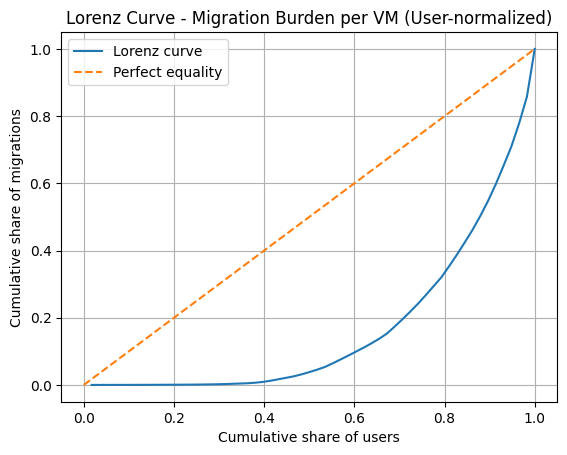

In [ ]:
lorenz_curve(
    user_migrations["migrations_per_vm"],
    title="Lorenz Curve - Migration Burden per VM (User-normalized)"
)

#### Jain's Fairness Index

In [14]:
def jains_fairness(x):
    x = np.array(x)
    return (np.sum(x) ** 2) / (len(x) * np.sum(x ** 2))

jain_user = jains_fairness(user_migrations["migrations_per_vm"])
print("Jain fairness (users):", jain_user)

Jain fairness (users): 0.3181396792790941


For Gini Coefficient, 0.66 is pretty high, it implies that a small fraction of users experience most of the migration load

- 0.0 – 0.3 → low inequality (fair-ish)
- 0.3 – 0.5 → moderate inequality
- 0.5 – 0.7 → high inequality

For Jain Coefficient, 0.318 suggests an unfair distribution: the system is far from fair in how migration burden is distributed. 
The system is not evenly distributing migration cost across tenants

“The observed Gini coefficient of 0.66 indicates a high level of inequality in migration distribution across users, while the corresponding Jain’s fairness index of 0.318 confirms that the system significantly deviates from an ideal fair allocation (Jain = 1). These results suggest that VM migrations are not uniformly distributed across tenants, but are instead concentrated on a subset of users.”